# EDA - Netflix Titles

Exploracion inicial del dataset **netflix_titles.csv** centrada en estas columnas:
- `show_id`
- `type`
- `title`
- `director`
- `cast`
- `country`
- `date_added`
- `release_year`
- `rating`
- `duration`

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

In [2]:
# Carga del dataset
df = pd.read_csv('../datasets/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
# Estructura general
print('Dimensiones:', df.shape)
print('\nTipos de datos:')
display(df.dtypes.to_frame('dtype'))

Dimensiones: (8807, 12)

Tipos de datos:


,dtype
show_id,str
type,str
title,str
director,str
cast,str
country,str
date_added,str
release_year,int64
rating,str
duration,str


In [4]:
# Nulos por columna
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df

,missing_count,missing_pct
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03
show_id,0,0.00
type,0,0.00
title,0,0.00
release_year,0,0.00


In [5]:
# Revisar unicidad de show_id
show_id_unique = df['show_id'].nunique()
print(f'show_id unicos: {show_id_unique}')
print(f'Filas totales: {len(df)}')
print('Hay duplicados en show_id:', show_id_unique != len(df))

show_id unicos: 8807
Filas totales: 8807
Hay duplicados en show_id: False


,count
type,
Movie,6131
TV Show,2676


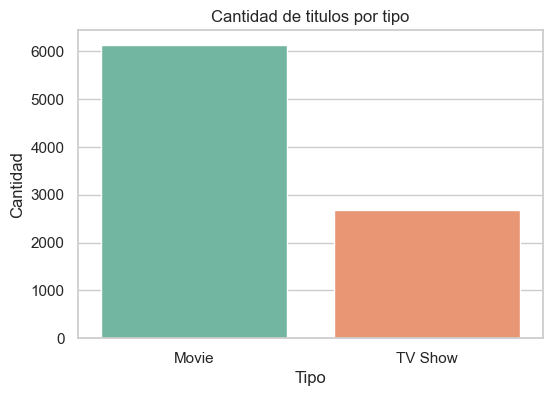

In [8]:
# Distribucion por tipo
type_counts = df['type'].value_counts(dropna=False)
display(type_counts.to_frame('count'))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='type', order=df['type'].value_counts().index, palette='Set2')
plt.title('Cantidad de titulos por tipo')
plt.xlabel('Tipo')
plt.ylabel('Cantidad')
plt.show()

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


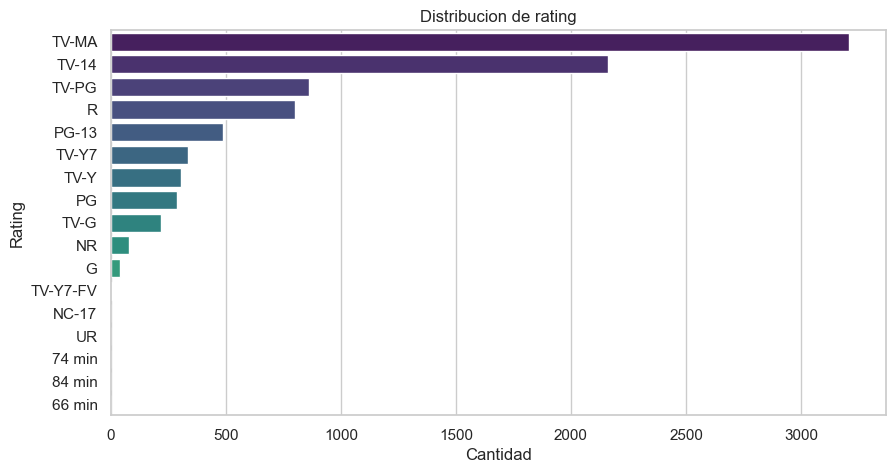

In [9]:
# Ratings mas frecuentes (clave para visualizaciones tipo treemap)
rating_counts = df['rating'].value_counts(dropna=False).head(15)
display(rating_counts.to_frame('count'))

plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='rating', order=df['rating'].value_counts().index, palette='viridis')
plt.title('Distribucion de rating')
plt.xlabel('Cantidad')
plt.ylabel('Rating')
plt.show()

,count
country_primary,
United States,3211
India,1008
Unknown,831
United Kingdom,628
Canada,271
Japan,259
France,212
South Korea,211
Spain,181


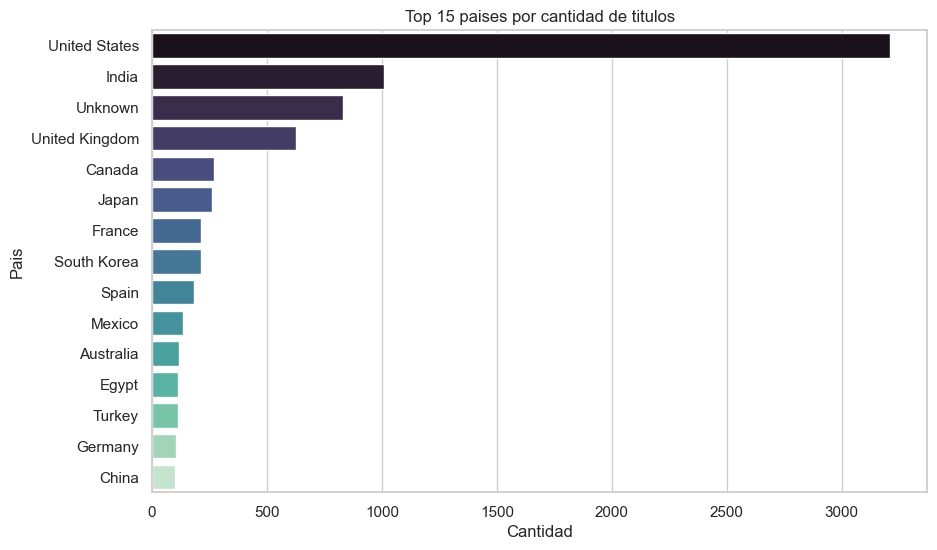

In [10]:
# Top paises (se toma el primer pais cuando hay multiples separados por coma)
df['country_primary'] = df['country'].fillna('Unknown').str.split(',').str[0].str.strip()
top_countries = df['country_primary'].value_counts().head(15)
display(top_countries.to_frame('count'))

plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='mako')
plt.title('Top 15 paises por cantidad de titulos')
plt.xlabel('Cantidad')
plt.ylabel('Pais')
plt.show()

,count
year_added,
2008.0,2
2009.0,2
2010.0,1
2011.0,13
2012.0,3
2013.0,10
2014.0,23
2015.0,73
2016.0,418


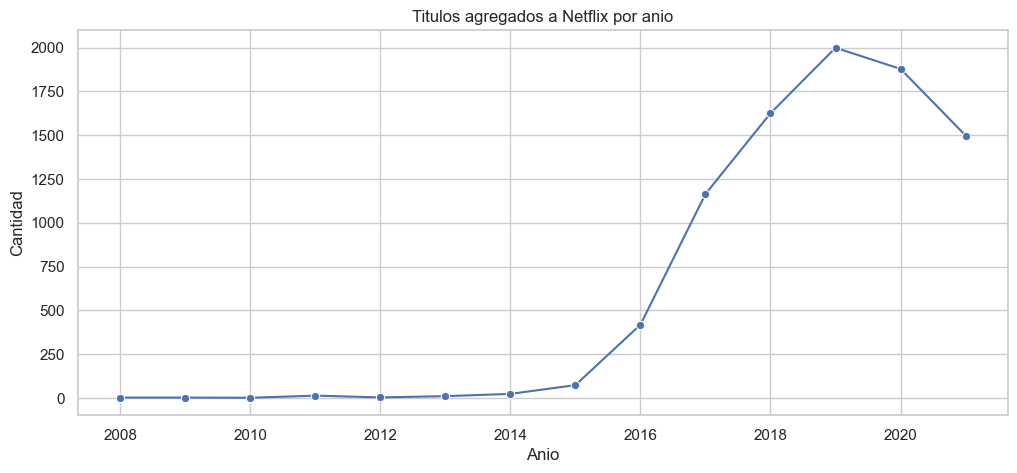

In [11]:
# Transformacion de date_added
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year

added_per_year = df['year_added'].value_counts().sort_index()
display(added_per_year.to_frame('count').tail(15))

plt.figure(figsize=(12, 5))
sns.lineplot(x=added_per_year.index, y=added_per_year.values, marker='o')
plt.title('Titulos agregados a Netflix por anio')
plt.xlabel('Anio')
plt.ylabel('Cantidad')
plt.show()

In [12]:
# Analisis de duration (minutos para Movie, temporadas para TV Show)
df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float)

movies = df[df['type'] == 'Movie'].copy()
tv_shows = df[df['type'] == 'TV Show'].copy()

print('Resumen duracion peliculas (min):')
display(movies['duration_num'].describe())

print('Resumen temporadas TV Shows:')
display(tv_shows['duration_num'].describe())

Resumen duracion peliculas (min):


count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_num, dtype: float64

Resumen temporadas TV Shows:


count    2676.000000
mean        1.764948
std         1.582752
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        17.000000
Name: duration_num, dtype: float64

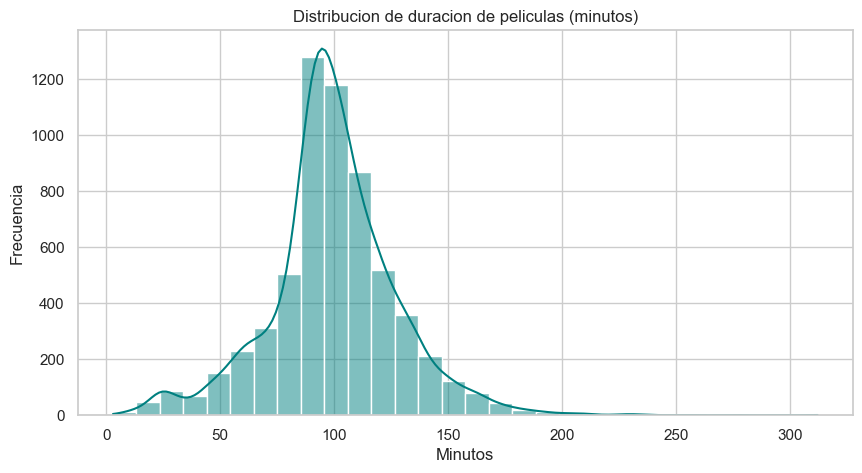

In [13]:
# Distribucion de duraciones de peliculas
plt.figure(figsize=(10, 5))
sns.histplot(movies['duration_num'].dropna(), bins=30, kde=True, color='teal')
plt.title('Distribucion de duracion de peliculas (minutos)')
plt.xlabel('Minutos')
plt.ylabel('Frecuencia')
plt.show()

In [14]:
# Variables solicitadas: vista rapida de cardinalidad
target_cols = ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration']
cardinality = pd.DataFrame({
    'n_unique': df[target_cols].nunique(dropna=True),
    'missing': df[target_cols].isna().sum(),
    'missing_pct': (df[target_cols].isna().sum() / len(df) * 100).round(2)
}).sort_values('missing_pct', ascending=False)
cardinality

,n_unique,missing,missing_pct
director,4528,2634,29.91
country,748,831,9.44
cast,7692,825,9.37
date_added,1699,98,1.11
rating,17,4,0.05
duration,220,3,0.03
type,2,0,0.00
show_id,8807,0,0.00
title,8807,0,0.00
release_year,74,0,0.00


## Hallazgos iniciales sugeridos

1. Identificar columnas con alto nivel de nulos (`director`, `cast`, `country`).
2. Confirmar dominancia de `Movie` vs `TV Show`.
3. Analizar `rating` para usarlo en una visualizacion tipo treemap en Tableau.
4. Separar analisis de `duration` para peliculas y series (minutos vs temporadas).
5. Observar tendencia temporal por `date_added` y `release_year`.

## Documentacion final (Fase 1)

### Hallazgos cuantitativos del analisis
- Registros: **8,807**.
- Atributos: **12**.
- Nulos principales: `director` (2,634), `country` (831), `cast` (825), `date_added` (10), `rating` (4), `duration` (3).
- Distribucion por tipo: `Movie` (6,131) y `TV Show` (2,676).
- Ratings mas frecuentes: `TV-MA` (3,207), `TV-14` (2,160), `TV-PG` (863), `R` (799), `PG-13` (490).
- Paises mas frecuentes (pais principal): Estados Unidos (3,211), India (1,008), Reino Unido (628), Canada (271).

### Interpretacion
- El dataset es util para analisis de catalogo, clasificacion por tipo de contenido y segmentacion por rating.
- La calidad de datos es buena en variables clave (`type`, `title`, `release_year`, `rating`, `duration`) y requiere tratamiento moderado en metadatos de produccion (`director`, `cast`, `country`).
- Es manejable para EDA en notebook y permite construir visualizaciones claras para comunicar hallazgos.

### Cumplimiento de criterios de Fase 1 para esta base
1. **Fuente y tipo de datos**: Cumple (tabular, fuente secundaria).
2. **Caracteristicas basicas**: Cumple (registros, atributos y tamano analizados).
3. **Nivel de documentacion y aplicaciones**: Cumple (columnas interpretable y casos de uso claros).
4. **Completitud, relevancia y manejabilidad**: Cumple (con observacion sobre nulos en `director`, `cast`, `country`).